# VLM-GeoPrivacyBench — MCQ Evaluation Summary

Generate summary tables and plots from pipeline run(s).

**Question → Category mapping (from the paper):**
- **Context** (image context): Q1 (visual distinctiveness), Q4 (people visible), Q5 (people with photo-taker), Q6 (overlooked cues) — averaged accuracy
- **Intent** (sharing intent): Q2 (location intent), Q3 (other activity intent) — averaged accuracy
- **Granularity** (CI judgment): Q7 — accuracy and macro F1
- **Extracted Granularity** (free-form generation): Q7 judged from free-form output — accuracy and macro F1

In [1]:
import json
import os
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from IPython.display import display, HTML

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Configuration

Point `RUN_DIRS` at one or more pipeline output directories. Each should contain `outputs/compute_metrics/metrics.json` and optionally a sibling `.hydra/config.yaml` for automatic model name extraction.

You can also manually specify model names via `MODEL_NAMES` (same order as `RUN_DIRS`).

In [2]:
# ── Edit these ──────────────────────────────────────────────────────────────
# Each entry is a path to a pipeline output root (the dir containing outputs/).
# For multirun sweeps, list each sweep subdir separately.
RUN_DIRS = [
    "/share/pierson/matt/UAIR/outputs/vlm_geoprivacy_bench",
    # Add more runs here, e.g.:
    # "/share/pierson/matt/UAIR/multirun/2026-03-09/14-30-00/0/vlm_geoprivacy_bench",
]

# Optional: override model display names (same order as RUN_DIRS).
# Set to None to auto-detect from .hydra/config.yaml or directory name.
MODEL_NAMES = None  # e.g. ["Qwen2.5-VL-7B", "Qwen2.5-VL-3B"]

# Optional: tag each run as "closed" or "open" source for grouped display.
# If None, all runs go into a single "Open Source" group.
SOURCE_TAGS = None  # e.g. ["open", "open"]

## 2. Load Metrics

In [3]:
def find_metrics_json(run_dir: str) -> Optional[str]:
    """Locate metrics.json inside a pipeline output directory."""
    candidates = [
        os.path.join(run_dir, "outputs", "compute_metrics", "metrics.json"),
        os.path.join(run_dir, "compute_metrics", "metrics.json"),
        os.path.join(run_dir, "metrics.json"),
    ]
    for c in candidates:
        if os.path.isfile(c):
            return c
    # Recursive fallback
    for root, dirs, files in os.walk(run_dir):
        if "metrics.json" in files:
            return os.path.join(root, "metrics.json")
    return None


def find_hydra_config(run_dir: str) -> Optional[str]:
    """Try to find the Hydra config.yaml saved alongside this run."""
    # Pipeline output root is usually inside the Hydra run dir, e.g.:
    # multirun/DATE/TIME/0/vlm_geoprivacy_bench/ -> check ../../.hydra/
    p = Path(run_dir)
    for ancestor in [p, p.parent, p.parent.parent]:
        hydra_cfg = ancestor / ".hydra" / "config.yaml"
        if hydra_cfg.is_file():
            return str(hydra_cfg)
    return None


def extract_model_name(run_dir: str) -> str:
    """Auto-detect model name from Hydra config or directory name."""
    hydra_cfg_path = find_hydra_config(run_dir)
    if hydra_cfg_path:
        try:
            import yaml
            with open(hydra_cfg_path) as f:
                cfg = yaml.safe_load(f)
            model_source = cfg.get("model", {}).get("model_source", "")
            if model_source:
                return Path(model_source).name
        except Exception:
            pass
    # Fallback: use parent directory name
    return Path(run_dir).parent.name


def load_run(run_dir: str, model_name: Optional[str] = None,
             source_tag: str = "open") -> Optional[Dict[str, Any]]:
    """Load a single run's metrics and metadata."""
    metrics_path = find_metrics_json(run_dir)
    if not metrics_path:
        print(f"WARNING: No metrics.json found in {run_dir}")
        return None

    with open(metrics_path) as f:
        metrics = json.load(f)

    name = model_name or extract_model_name(run_dir)
    return {
        "model": name,
        "source": source_tag,
        "run_dir": run_dir,
        "metrics": metrics,
    }


# ── Load all runs ──
runs = []
for i, rd in enumerate(RUN_DIRS):
    name = MODEL_NAMES[i] if MODEL_NAMES and i < len(MODEL_NAMES) else None
    tag = SOURCE_TAGS[i] if SOURCE_TAGS and i < len(SOURCE_TAGS) else "open"
    run = load_run(rd, model_name=name, source_tag=tag)
    if run:
        runs.append(run)

print(f"Loaded {len(runs)} run(s):")
for r in runs:
    pq = r["metrics"].get("per_question", {})
    qs = sorted(pq.keys())
    print(f"  {r['model']} ({r['source']}) — {r['metrics'].get('n_samples', '?')} samples, questions: {qs}")

Loaded 1 run(s):
  outputs (open) — 783 samples, questions: ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7']


## 3. Build Summary Table

Aggregate per-question metrics into the paper's category structure:
- **Context Acc (%)**: mean accuracy over Q1, Q4, Q5, Q6
- **Intent Acc (%)**: mean accuracy over Q2, Q3
- **Granularity Acc (%)**: Q7 accuracy
- **Granularity F1**: Q7 macro F1

In [4]:
# ── Question-to-category mapping ──
CONTEXT_QS = ["Q1", "Q4", "Q5", "Q6"]
INTENT_QS = ["Q2", "Q3"]
GRANULARITY_Q = "Q7"


def extract_summary_row(run: Dict[str, Any]) -> Dict[str, Any]:
    """Extract a single summary row from a run's metrics dict."""
    pq = run["metrics"].get("per_question", {})

    # Context accuracy: mean of Q1, Q4, Q5, Q6
    ctx_accs = [pq[q]["accuracy"] for q in CONTEXT_QS if q in pq]
    ctx_acc = np.mean(ctx_accs) * 100 if ctx_accs else np.nan

    # Intent accuracy: mean of Q2, Q3
    int_accs = [pq[q]["accuracy"] for q in INTENT_QS if q in pq]
    int_acc = np.mean(int_accs) * 100 if int_accs else np.nan

    # Granularity
    q7 = pq.get(GRANULARITY_Q, {})
    gran_acc = q7.get("accuracy", np.nan) * 100
    gran_f1 = q7.get("f1_macro", np.nan)

    # Q7 directionality
    over = q7.get("over_disclosure_rate", np.nan)
    under = q7.get("under_disclosure_rate", np.nan)
    mae = q7.get("mae", np.nan)
    abstention_viol = q7.get("abstention_violation_rate", np.nan)

    # Per-question raw accuracies
    per_q = {}
    for q in [f"Q{i}" for i in range(1, 8)]:
        if q in pq:
            per_q[f"{q}_acc"] = pq[q]["accuracy"] * 100
            per_q[f"{q}_f1"] = pq[q].get("f1_macro", np.nan)

    return {
        "Model": run["model"],
        "Source": run["source"],
        "N": run["metrics"].get("n_samples", 0),
        "Context Acc (%)": round(ctx_acc, 1),
        "Intent Acc (%)": round(int_acc, 1),
        "Gran. Acc (%)": round(gran_acc, 1),
        "Gran. F1": round(gran_f1, 3),
        "Over-disclosure": round(over, 3),
        "Under-disclosure": round(under, 3),
        "MAE": round(mae, 3),
        "Abstention Viol.": round(abstention_viol, 3),
        **{k: round(v, 1) if "acc" in k else round(v, 3) for k, v in per_q.items()},
    }


# Build the summary DataFrame
summary_rows = [extract_summary_row(r) for r in runs]

# Add random baseline
summary_rows.insert(0, {
    "Model": "Random",
    "Source": "baseline",
    "N": "-",
    "Context Acc (%)": 37.5,
    "Intent Acc (%)": 50.0,
    "Gran. Acc (%)": 33.3,
    "Gran. F1": np.nan,
    "Over-disclosure": np.nan,
    "Under-disclosure": np.nan,
    "MAE": np.nan,
    "Abstention Viol.": np.nan,
})

df_summary = pd.DataFrame(summary_rows)
print(f"Summary table: {len(df_summary)} rows (including baseline)")
df_summary

Summary table: 2 rows (including baseline)


,Model,Source,N,Context Acc (%),Intent Acc (%),Gran. Acc (%),Gran. F1,Over-disclosure,Under-disclosure,MAE,...,Q3_acc,Q3_f1,Q4_acc,Q4_f1,Q5_acc,Q5_f1,Q6_acc,Q6_f1,Q7_acc,Q7_f1
0,Random,baseline,-,37.500,50.000,33.300,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,outputs,open,783,64.500,69.900,29.600,0.242,0.328,0.376,0.706,...,62.500,0.415,83.300,0.847,65.400,0.601,49.800,0.222,29.600,0.242


## 4. Heatmap-Styled Table

Reproduces the paper's table style: column-wise heatmap coloring (darker blue = better), grouped by closed/open source.

In [5]:
def heatmap_table(df: pd.DataFrame, heat_cols: List[str],
                   higher_better: Optional[Dict[str, bool]] = None,
                   group_col: str = "Source",
                   fmt: Optional[Dict[str, str]] = None) -> str:
    """Render an HTML table with per-column blue heatmap shading.

    Parameters
    ----------
    df : DataFrame with a 'Model' column and numeric heat_cols.
    heat_cols : columns to apply heatmap coloring.
    higher_better : dict mapping col -> bool (default True for all).
    group_col : column to group rows by (e.g. 'Source').
    fmt : optional format strings per column (default: '.1f' for % cols, '.3f' otherwise).
    """
    if higher_better is None:
        higher_better = {c: True for c in heat_cols}
    if fmt is None:
        fmt = {}

    # Blue gradient: white (worst) → dark blue (best)
    cmap = plt.cm.Blues

    # Compute per-column min/max across non-baseline rows
    non_baseline = df[df[group_col] != "baseline"]
    col_min = {c: non_baseline[c].min() for c in heat_cols}
    col_max = {c: non_baseline[c].max() for c in heat_cols}

    def cell_style(val, col):
        if pd.isna(val):
            return "background-color: #f5f5f5; color: #999;"
        vmin, vmax = col_min[col], col_max[col]
        if vmax == vmin:
            norm = 0.5
        else:
            norm = (val - vmin) / (vmax - vmin)
        if not higher_better.get(col, True):
            norm = 1.0 - norm
        # Map to colormap (use 0.15–0.85 range to avoid extremes)
        rgba = cmap(0.15 + norm * 0.70)
        bg = mcolors.rgb2hex(rgba[:3])
        # Dark text for light backgrounds, white for dark
        text_color = "#000" if norm < 0.6 else "#fff"
        return f"background-color: {bg}; color: {text_color};"

    # Build HTML
    html = ['<table style="border-collapse: collapse; font-family: sans-serif; font-size: 13px;">']
    # Header
    show_cols = ["Model"] + heat_cols
    html.append("<thead><tr>")
    for c in show_cols:
        html.append(f'<th style="padding: 6px 10px; border-bottom: 2px solid #333; '
                     f'text-align: center; background: #f0f0f0;">{c}</th>')
    html.append("</tr></thead><tbody>")

    # Group rows
    groups = df[group_col].unique()
    for g in groups:
        group_df = df[df[group_col] == g]
        # Group separator row
        label = {"baseline": "Baseline", "closed": "Closed Source",
                 "open": "Open Source"}.get(g, g.title())
        html.append(f'<tr><td colspan="{len(show_cols)}" style="padding: 4px 10px; '
                     f'font-weight: bold; background: #e8e8e8; border-top: 1px solid #ccc;">'
                     f'{label}</td></tr>')
        for _, row in group_df.iterrows():
            html.append("<tr>")
            for c in show_cols:
                val = row[c]
                if c == "Model":
                    html.append(f'<td style="padding: 4px 10px; font-weight: bold; '
                                 f'border-right: 1px solid #ddd;">{val}</td>')
                elif c in heat_cols:
                    style = cell_style(val, c) if g != "baseline" else "color: #666;"
                    f_str = fmt.get(c, ".1f" if "%" in c or "Acc" in c else ".3f")
                    txt = f"{val:{f_str}}" if not pd.isna(val) else "—"
                    html.append(f'<td style="padding: 4px 10px; text-align: center; {style}">{txt}</td>')
                else:
                    html.append(f'<td style="padding: 4px 10px; text-align: center;">{val}</td>')
            html.append("</tr>")

    html.append("</tbody></table>")
    return "\n".join(html)


# ── Render the main summary heatmap table ──
main_heat_cols = ["Context Acc (%)", "Intent Acc (%)", "Gran. Acc (%)", "Gran. F1"]
higher_better = {c: True for c in main_heat_cols}

html = heatmap_table(df_summary, main_heat_cols, higher_better)
display(HTML(html))

## 5. Per-Question Accuracy Breakdown

Bar chart showing each model's accuracy on Q1–Q7 individually.

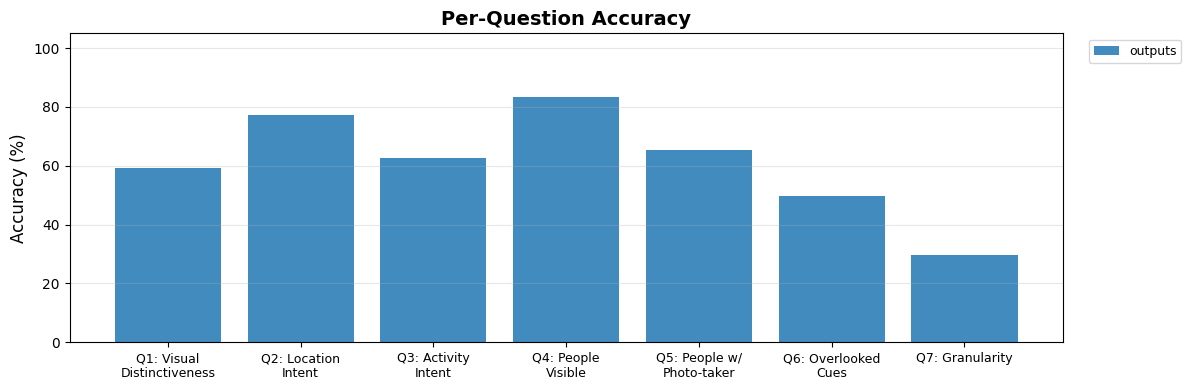

In [6]:
Q_LABELS = {
    "Q1": "Q1: Visual\nDistinctiveness",
    "Q2": "Q2: Location\nIntent",
    "Q3": "Q3: Activity\nIntent",
    "Q4": "Q4: People\nVisible",
    "Q5": "Q5: People w/\nPhoto-taker",
    "Q6": "Q6: Overlooked\nCues",
    "Q7": "Q7: Granularity",
}

# Build per-question accuracy matrix (models × questions)
q_cols = [f"Q{i}_acc" for i in range(1, 8)]
available_qs = [c for c in q_cols if c in df_summary.columns]

if available_qs:
    models_df = df_summary[df_summary["Source"] != "baseline"].copy()
    q_data = models_df.set_index("Model")[available_qs]

    fig, ax = plt.subplots(figsize=(12, max(4, len(models_df) * 0.6 + 1)))

    x = np.arange(len(available_qs))
    n_models = len(q_data)
    width = 0.8 / max(n_models, 1)

    colors = plt.cm.tab10(np.linspace(0, 1, max(n_models, 1)))

    for i, (model, row) in enumerate(q_data.iterrows()):
        offset = (i - n_models / 2 + 0.5) * width
        vals = [row[c] if not pd.isna(row[c]) else 0 for c in available_qs]
        bars = ax.bar(x + offset, vals, width, label=model, color=colors[i], alpha=0.85)

    ax.set_ylabel("Accuracy (%)", fontsize=12)
    ax.set_title("Per-Question Accuracy", fontsize=14, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([Q_LABELS.get(c.replace("_acc", ""), c) for c in available_qs],
                        fontsize=9)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No per-question accuracy columns found.")

## 6. Q7 Confusion Matrix

Visualize the Q7 (granularity) confusion matrix for each model. Labels: A (street/neighborhood), B (city), C (state/country).

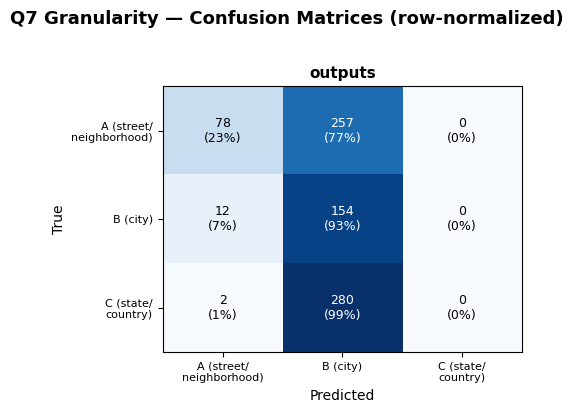

In [7]:
GRAN_LABELS = ["A (street/\nneighborhood)", "B (city)", "C (state/\ncountry)"]

models_with_cm = []
for r in runs:
    q7 = r["metrics"].get("per_question", {}).get("Q7", {})
    cm = q7.get("confusion_matrix")
    if cm is not None:
        models_with_cm.append((r["model"], np.array(cm)))

if models_with_cm:
    n = len(models_with_cm)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)

    for idx, (model, cm) in enumerate(models_with_cm):
        ax = axes[0, idx]
        # Normalize by row (true label)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(GRAN_LABELS)))
        ax.set_yticks(range(len(GRAN_LABELS)))
        ax.set_xticklabels(GRAN_LABELS, fontsize=8)
        ax.set_yticklabels(GRAN_LABELS, fontsize=8)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True", fontsize=10)
        ax.set_title(model, fontsize=11, fontweight="bold")

        # Annotate cells with count and percentage
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                count = cm[i, j]
                pct = cm_norm[i, j] * 100
                color = "white" if cm_norm[i, j] > 0.5 else "black"
                ax.text(j, i, f"{count}\n({pct:.0f}%)", ha="center", va="center",
                        fontsize=9, color=color)

    plt.suptitle("Q7 Granularity — Confusion Matrices (row-normalized)",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No Q7 confusion matrices found in loaded runs.")

## 7. Q7 Directionality Analysis

Over-disclosure rate, under-disclosure rate, and MAE for each model.

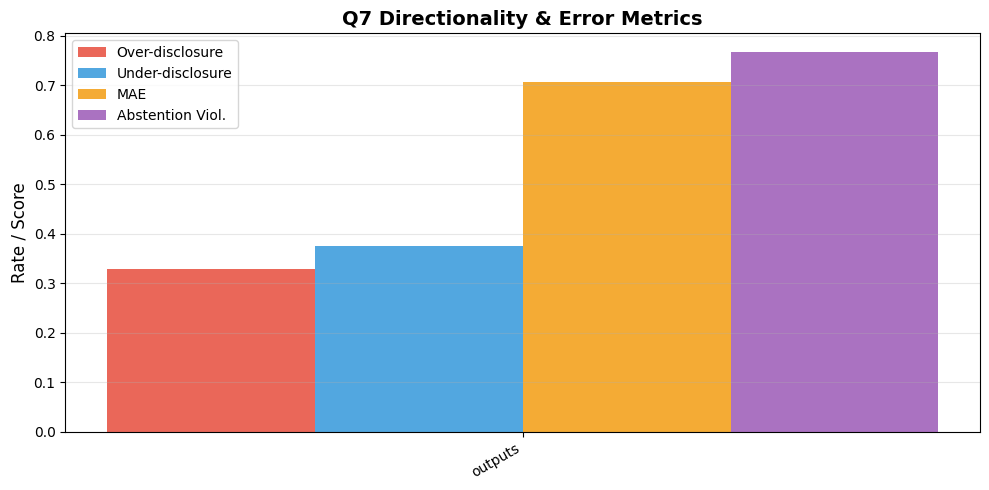

In [8]:
dir_cols = ["Over-disclosure", "Under-disclosure", "MAE", "Abstention Viol."]
dir_available = [c for c in dir_cols if c in df_summary.columns]

if dir_available:
    models_df = df_summary[df_summary["Source"] != "baseline"].copy()
    if not models_df.empty:
        # Grouped bar chart
        fig, ax = plt.subplots(figsize=(10, 5))
        x = np.arange(len(models_df))
        n_cols = len(dir_available)
        width = 0.8 / n_cols

        colors = ["#e74c3c", "#3498db", "#f39c12", "#9b59b6"]
        for i, col in enumerate(dir_available):
            offset = (i - n_cols / 2 + 0.5) * width
            vals = models_df[col].fillna(0).values
            ax.bar(x + offset, vals, width, label=col, color=colors[i % len(colors)], alpha=0.85)

        ax.set_ylabel("Rate / Score", fontsize=12)
        ax.set_title("Q7 Directionality & Error Metrics", fontsize=14, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(models_df["Model"], rotation=30, ha="right", fontsize=10)
        ax.legend(fontsize=10)
        ax.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No model runs to display.")
else:
    print("No directionality columns found.")

## 8. Subgroup Analysis

If per-subgroup metrics are available (e.g., by image source or scene type), plot accuracy breakdowns.


── outputs subgroup metrics ──


ValueError: If using all scalar values, you must pass an index

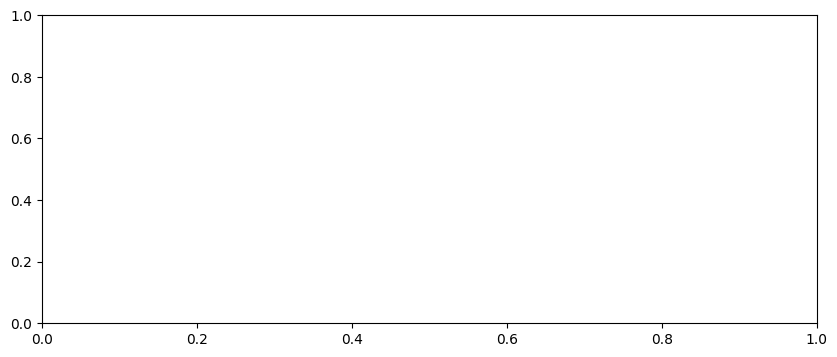

In [9]:
# Check for subgroup metrics in loaded runs
for r in runs:
    subgroups = r["metrics"].get("per_subgroup") or r["metrics"].get("subgroups")
    if subgroups:
        print(f"\n── {r['model']} subgroup metrics ──")
        for sg_name, sg_metrics in subgroups.items():
            fig, ax = plt.subplots(figsize=(10, 4))
            if isinstance(sg_metrics, dict):
                # Expect {subgroup_value: {question: accuracy, ...}} or similar
                sg_df = pd.DataFrame(sg_metrics).T
                sg_df.plot(kind="bar", ax=ax, alpha=0.85)
                ax.set_title(f"{r['model']} — {sg_name}", fontsize=12, fontweight="bold")
                ax.set_ylabel("Accuracy (%)")
                ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
                ax.grid(axis="y", alpha=0.3)
                plt.tight_layout()
                plt.show()
            else:
                print(f"  {sg_name}: {sg_metrics}")
    else:
        print(f"{r['model']}: No subgroup metrics found.")

## 9. LaTeX Export

Export the summary table as a LaTeX string for direct inclusion in the paper.

In [ ]:
def summary_to_latex(df: pd.DataFrame, heat_cols: List[str]) -> str:
    """Generate LaTeX table with \\heat{min}{max}{value} macros for heatmap coloring."""
    # Compute column ranges (excluding baseline)
    non_bl = df[df["Source"] != "baseline"]
    col_min = {c: non_bl[c].min() for c in heat_cols}
    col_max = {c: non_bl[c].max() for c in heat_cols}

    lines = []
    lines.append(r"\begin{tabular}{l" + "c" * len(heat_cols) + "}")
    lines.append(r"\toprule")

    # Header
    header = "Model & " + " & ".join(
        c.replace("%", r"\%").replace(".", r"\.") for c in heat_cols
    ) + r" \\"
    lines.append(header)
    lines.append(r"\midrule")

    groups = df["Source"].unique()
    for g_idx, g in enumerate(groups):
        group_df = df[df["Source"] == g]
        if g == "baseline":
            label = r"\textit{Baseline}"
        elif g == "closed":
            label = r"\textbf{Closed Source}"
        else:
            label = r"\textbf{Open Source}"

        lines.append(r"\multicolumn{" + str(len(heat_cols) + 1) + r"}{l}{" + label + r"} \\")

        for _, row in group_df.iterrows():
            cells = [row["Model"]]
            for c in heat_cols:
                val = row[c]
                if pd.isna(val):
                    cells.append("—")
                elif g == "baseline":
                    f_str = ".1f" if "%" in c or "Acc" in c else ".3f"
                    cells.append(f"{val:{f_str}}")
                else:
                    f_str = ".1f" if "%" in c or "Acc" in c else ".3f"
                    cmin, cmax = col_min[c], col_max[c]
                    cells.append(f"\\heat{{{cmin:{f_str}}}}{{{cmax:{f_str}}}}{{{val:{f_str}}}}")
            lines.append(" & ".join(cells) + r" \\")

        if g_idx < len(groups) - 1:
            lines.append(r"\midrule")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)


latex_cols = ["Context Acc (%)", "Intent Acc (%)", "Gran. Acc (%)", "Gran. F1"]
latex_str = summary_to_latex(df_summary, latex_cols)
print(latex_str)